In [1]:
# ==========================================================
# SECTION 1 : IMPORT LIBRARIES
# COVID VGG16 BASELINE
# ==========================================================

import os
import random
import shutil
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import VGG16

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger
)

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 70)
print("COVID-19 RADIOGRAPHY DATABASE")
print("VGG16 BASELINE MODEL")
print("=" * 70)

print("TensorFlow Version :", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU Available :", gpus[0].name)
else:
    print("GPU Not Available")

print("=" * 70)

COVID-19 RADIOGRAPHY DATABASE
VGG16 BASELINE MODEL
TensorFlow Version : 2.20.0
GPU Available : /physical_device:GPU:0


In [2]:
# ==========================================================
# SECTION 2 : KAGGLE API SETUP
# ==========================================================

from google.colab import files

print("="*70)
print("UPLOAD kaggle.json")
print("="*70)

uploaded = files.upload()

!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

print("="*70)
print("Kaggle API Configured Successfully")
print("="*70)

UPLOAD kaggle.json


Saving kaggle.json to kaggle.json
Kaggle API Configured Successfully


In [3]:
# ==========================================================
# SECTION 3 : DOWNLOAD COVID-19 RADIOGRAPHY DATABASE
# ==========================================================

DATASET = "tawsifurrahman/covid19-radiography-database"

!kaggle datasets download -d $DATASET

print("="*70)
print("Dataset Downloaded Successfully")
print("="*70)

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
100% 778M/778M [00:06<00:00, 135MB/s] 

Dataset Downloaded Successfully


In [4]:
# ==========================================================
# SECTION 4 : EXTRACT DATASET
# ==========================================================

import zipfile
import os

ZIP_FILE = "/content/covid19-radiography-database.zip"

EXTRACT_PATH = "/content/Covid_Data_set"

with zipfile.ZipFile(ZIP_FILE, "r") as zip_ref:

    zip_ref.extractall(EXTRACT_PATH)

print("="*70)
print("Dataset Extracted Successfully")
print("="*70)

SOURCE_DIR = "/content/Covid_Data_set/COVID-19_Radiography_Dataset"

DEST_DIR = "/content/Covid_Split"

print("Source Directory :", SOURCE_DIR)

print("Destination :", DEST_DIR)

Dataset Extracted Successfully
Source Directory : /content/Covid_Data_set/COVID-19_Radiography_Dataset
Destination : /content/Covid_Split


In [5]:
# ==========================================================
# SECTION 5 : DATASET SPLIT
# ==========================================================

import os
import shutil
from sklearn.model_selection import train_test_split

print("="*70)
print("COVID DATASET SPLITTING")
print("="*70)

os.makedirs(DEST_DIR, exist_ok=True)

for split in ["train","validation","test"]:

    os.makedirs(

        os.path.join(DEST_DIR, split),

        exist_ok=True

    )

classes = [

    "COVID",

    "Lung_Opacity",

    "Normal",

    "Viral Pneumonia"

]

for cls in classes:

    print(f"\nProcessing : {cls}")

    source_images = os.path.join(

        SOURCE_DIR,

        cls,

        "images"

    )

    images = [

        img for img in os.listdir(source_images)

        if img.lower().endswith(

            (".png",".jpg",".jpeg")

        )

    ]

    train_imgs, temp_imgs = train_test_split(

        images,

        test_size=0.30,

        random_state=42,

        shuffle=True

    )

    val_imgs, test_imgs = train_test_split(

        temp_imgs,

        test_size=0.50,

        random_state=42,

        shuffle=True

    )

    for split in ["train","validation","test"]:

        os.makedirs(

            os.path.join(

                DEST_DIR,

                split,

                cls

            ),

            exist_ok=True

        )

    for img in train_imgs:

        shutil.copy2(

            os.path.join(source_images,img),

            os.path.join(

                DEST_DIR,

                "train",

                cls,

                img

            )

        )

    for img in val_imgs:

        shutil.copy2(

            os.path.join(source_images,img),

            os.path.join(

                DEST_DIR,

                "validation",

                cls,

                img

            )

        )

    for img in test_imgs:

        shutil.copy2(

            os.path.join(source_images,img),

            os.path.join(

                DEST_DIR,

                "test",

                cls,

                img

            )

        )

    print(f"Train      : {len(train_imgs)}")

    print(f"Validation : {len(val_imgs)}")

    print(f"Test       : {len(test_imgs)}")

print("\n"+"="*70)

print("Dataset Split Completed")

print("="*70)

for split in ["train","validation","test"]:

    total = 0

    for cls in classes:

        total += len(

            os.listdir(

                os.path.join(

                    DEST_DIR,

                    split,

                    cls

                )

            )

        )

    print(f"{split:<12}: {total} images")

COVID DATASET SPLITTING

Processing : COVID
Train      : 2531
Validation : 542
Test       : 543

Processing : Lung_Opacity
Train      : 4208
Validation : 902
Test       : 902

Processing : Normal
Train      : 7134
Validation : 1529
Test       : 1529

Processing : Viral Pneumonia
Train      : 941
Validation : 202
Test       : 202

Dataset Split Completed
train       : 14814 images
validation  : 3175 images
test        : 3176 images


In [6]:
# ==========================================================
# SECTION 6 : DATA GENERATORS
# ==========================================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (224,224)

BATCH_SIZE = 60

TRAIN_PATH = "/content/Covid_Split/train"
VALID_PATH = "/content/Covid_Split/validation"
TEST_PATH  = "/content/Covid_Split/test"

train_datagen = ImageDataGenerator(
    rescale=1./255
)

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(

    TRAIN_PATH,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=True

)

valid_generator = valid_datagen.flow_from_directory(

    VALID_PATH,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=False

)

test_generator = test_datagen.flow_from_directory(

    TEST_PATH,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    shuffle=False

)

print("="*70)
print("Training Images   :", train_generator.samples)
print("Validation Images :", valid_generator.samples)
print("Testing Images    :", test_generator.samples)
print("Steps Per Epoch   :", len(train_generator))
print("="*70)

Found 14814 images belonging to 4 classes.
Found 3175 images belonging to 4 classes.
Found 3176 images belonging to 4 classes.
Training Images   : 14814
Validation Images : 3175
Testing Images    : 3176
Steps Per Epoch   : 247


In [7]:
# ==========================================================
# SECTION 7 : LOAD PRETRAINED VGG16
# ==========================================================

from tensorflow.keras.applications import VGG16

base_model = VGG16(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)

)

print("="*70)
print("VGG16 Loaded Successfully")
print("="*70)

print("Total Layers :", len(base_model.layers))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 Loaded Successfully
Total Layers : 19


In [8]:
# ==========================================================
# SECTION 8 : FREEZE VGG16
# ==========================================================

for layer in base_model.layers:

    layer.trainable = False

print("="*70)
print("Frozen Layers :", len(base_model.layers))
print("="*70)

Frozen Layers : 19


In [9]:
# ==========================================================
# SECTION 9 : CLASSIFICATION HEAD
# ==========================================================

from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

from tensorflow.keras.models import Model

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(

    256,

    activation="relu"

)(x)

x = Dropout(

    0.5

)(x)

output = Dense(

    4,

    activation="softmax"

)(x)

model = Model(

    inputs=base_model.input,

    outputs=output

)

print("="*70)
print("Classification Head Added Successfully")
print("="*70)

model.summary()

Classification Head Added Successfully


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
# ==========================================================
# SECTION 10 : COMPILE MODEL
# ==========================================================

from tensorflow.keras.optimizers import Adam

optimizer = Adam(

    learning_rate=0.001

)

model.compile(

    optimizer=optimizer,

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

print("="*70)
print("Model Compiled Successfully")
print("="*70)

print("Optimizer     : Adam")
print("Learning Rate :", optimizer.learning_rate.numpy())
print("Loss          : categorical_crossentropy")
print("Metric        : accuracy")

Model Compiled Successfully
Optimizer     : Adam
Learning Rate : 0.001
Loss          : categorical_crossentropy
Metric        : accuracy


In [16]:
# ==========================================================
# SECTION 11 : GOOGLE DRIVE + CALLBACKS
# ==========================================================

from google.colab import drive
drive.mount('/content/drive')

import os

from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger
)

# ----------------------------------------------------------
# Save Folder
# ----------------------------------------------------------

SAVE_DIR = "/content/drive/MyDrive/Research_paper/COVID_VGG16"

os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_PATH = os.path.join(
    SAVE_DIR,
    "best_covid_vgg16.keras"
)

CSV_PATH = os.path.join(
    SAVE_DIR,
    "training_log.csv"
)

# ----------------------------------------------------------
# Callbacks
# ----------------------------------------------------------

checkpoint = ModelCheckpoint(

    filepath=MODEL_PATH,

    monitor="val_accuracy",

    mode="max",

    save_best_only=True,

    save_weights_only=False,

    verbose=1

)

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=10,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.1,

    patience=5,

    min_lr=1e-6,

    verbose=1

)

csv_logger = CSVLogger(

    CSV_PATH,

    append=True

)

callbacks = [

    checkpoint,

    early_stop,

    reduce_lr,

    csv_logger

]

print("="*70)
print("Google Drive Mounted Successfully")
print("="*70)

print("Model Path :")
print(MODEL_PATH)

print()

print("CSV Log Path :")
print(CSV_PATH)

print("="*70)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive Mounted Successfully
Model Path :
/content/drive/MyDrive/Research_paper/COVID_VGG16/best_covid_vgg16.keras

CSV Log Path :
/content/drive/MyDrive/Research_paper/COVID_VGG16/training_log.csv


In [17]:
# ==========================================================
# SECTION 12 : LOAD MODEL (IF EXISTS)
# ==========================================================

from tensorflow.keras.models import load_model
import os

EPOCHS = 100

# ----------------------------------------------------------
# Check Previous Model
# ----------------------------------------------------------

if os.path.exists(MODEL_PATH):

    print("="*70)
    print("Previous Model Found")
    print("Loading Saved Model...")
    print("="*70)

    model = load_model(MODEL_PATH)

else:

    print("="*70)
    print("No Previous Model Found")
    print("Starting Fresh Model")
    print("="*70)

print("Model Ready For Training")

No Previous Model Found
Starting Fresh Model
Model Ready For Training


In [18]:
# ==========================================================
# SECTION 12 : TRAIN MODEL
# ==========================================================

EPOCHS = 100

history = model.fit(

    train_generator,

    validation_data=valid_generator,

    epochs=EPOCHS,

    callbacks=callbacks,

    verbose=1

)

print("="*70)
print("Training Completed Successfully")
print("="*70)

Epoch 1/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.7466 - loss: 0.6739
Epoch 1: val_accuracy improved from None to 0.79528, saving model to /content/drive/MyDrive/Research_paper/COVID_VGG16/best_covid_vgg16.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Research_paper/COVID_VGG16/best_covid_vgg16.keras
247/247 ━━━━━━━━━━━━━━━━━━━━ 104s 422ms/step - accuracy: 0.7558 - loss: 0.6502 - val_accuracy: 0.7953 - val_loss: 0.5827 - learning_rate: 0.0010
Epoch 2/100
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.7873 - loss: 0.5891
Epoch 2: val_accuracy improved from 0.79528 to 0.82740, saving model to /content/drive/MyDrive/Research_paper/COVID_VGG16/best_covid_vgg16.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Research_paper/COVID_VGG16/best_covid_vgg16.keras
247/247 ━━━━━━━━━━━━━━━━━━━━ 88s 357ms/step - accuracy: 0.7914 - loss: 0.5691 - val_accuracy: 0.8274 - val_loss: 0.4966 - learning_rate: 0.0010
Epoch 3/100
247/247 ━━━━━━━━━━

In [20]:
from tensorflow.keras.models import load_model

best_model = load_model(MODEL_PATH)

print("="*60)
print("Best Model Loaded Successfully")
print("="*60)

Best Model Loaded Successfully


In [21]:
# ==========================================================
# SECTION 14 : TEST EVALUATION
# ==========================================================

test_loss, test_accuracy = best_model.evaluate(
    test_generator,
    verbose=1
)

print("="*60)
print("TEST RESULTS")
print("="*60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")

53/53 ━━━━━━━━━━━━━━━━━━━━ 34s 603ms/step - accuracy: 0.9059 - loss: 0.2740
TEST RESULTS
Test Loss     : 0.2740
Test Accuracy : 90.59%


In [22]:
# ==========================================================
# SECTION 15 : PREDICTIONS
# ==========================================================

import numpy as np

test_generator.reset()

predictions = best_model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = test_generator.classes

print("="*60)
print("Predictions Completed")
print("="*60)

53/53 ━━━━━━━━━━━━━━━━━━━━ 16s 283ms/step
Predictions Completed


In [23]:
# ==========================================================
# SECTION 16 : CLASSIFICATION REPORT
# ==========================================================

from sklearn.metrics import classification_report

class_names = list(test_generator.class_indices.keys())

print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

CLASSIFICATION REPORT
                 precision    recall  f1-score   support

          COVID     0.9593    0.8692    0.9121       543
   Lung_Opacity     0.9045    0.8404    0.8713       902
         Normal     0.8826    0.9588    0.9191      1529
Viral Pneumonia     0.9784    0.8960    0.9354       202

       accuracy                         0.9059      3176
      macro avg     0.9312    0.8911    0.9095      3176
   weighted avg     0.9080    0.9059    0.9054      3176



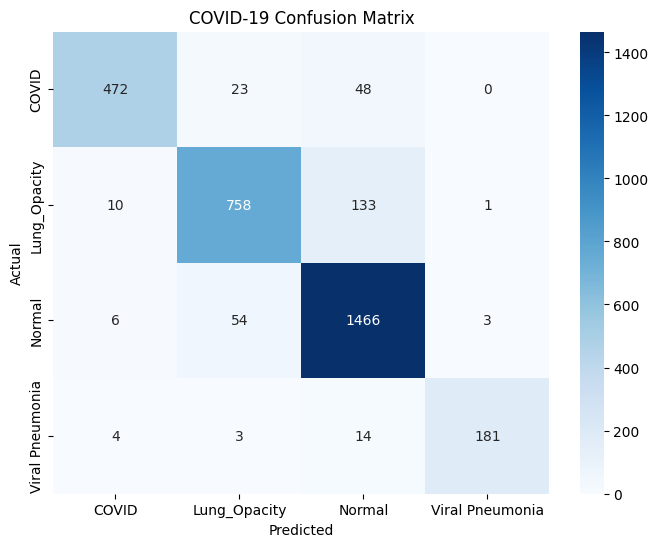

In [25]:
# ==========================================================
# SECTION 17 : CONFUSION MATRIX
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=class_names,

    yticklabels=class_names

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("COVID-19 Confusion Matrix")

plt.show()

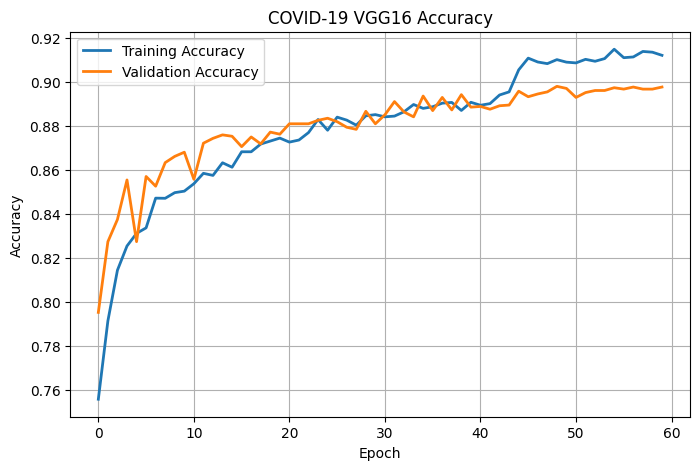

In [26]:
# ==========================================================
# SECTION 18 : ACCURACY GRAPH
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(

    history.history["accuracy"],

    label="Training Accuracy",

    linewidth=2

)

plt.plot(

    history.history["val_accuracy"],

    label="Validation Accuracy",

    linewidth=2

)

plt.title("COVID-19 VGG16 Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

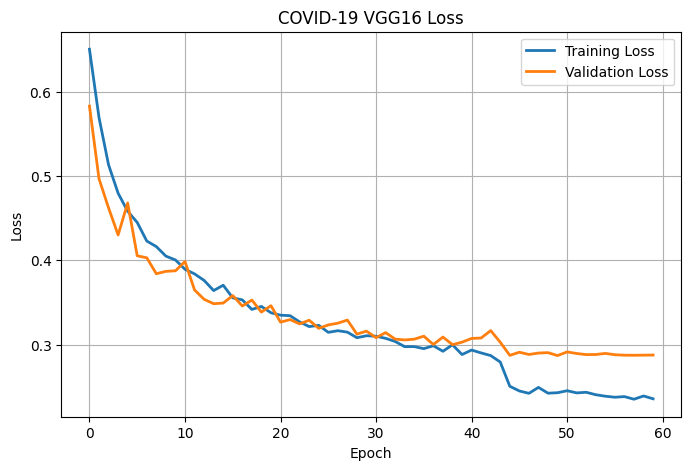

In [27]:
# ==========================================================
# SECTION 19 : LOSS GRAPH
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(

    history.history["loss"],

    label="Training Loss",

    linewidth=2

)

plt.plot(

    history.history["val_loss"],

    label="Validation Loss",

    linewidth=2

)

plt.title("COVID-19 VGG16 Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

In [28]:
# ==========================================================
# SECTION 20 : SAVE RESULTS
# ==========================================================

import pandas as pd

results = {

    "Test Accuracy":[test_accuracy],

    "Test Loss":[test_loss]

}

results_df = pd.DataFrame(results)

RESULT_PATH = "/content/drive/MyDrive/Research_paper/COVID_VGG16/final_results.csv"

results_df.to_csv(

    RESULT_PATH,

    index=False

)

print("="*60)

print("COVID BASELINE COMPLETED")

print("="*60)

print("Results Saved At:")

print(RESULT_PATH)

COVID BASELINE COMPLETED
Results Saved At:
/content/drive/MyDrive/Research_paper/COVID_VGG16/final_results.csv
